In [ ]:
# python ./svraster/train.py \
#     --eval \
#     --source_path /home/dotamthuc-3090/Projects/ViewSynthesis/data/360_v2/kitchen \
#     --model_path /home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04 \
#     --lambda_normal_dmean 0.001 --lambda_normal_dmed 0.001 \
#     --res_downscale 8 \
#     --test_every 20 \
#     --ss 1.0 \
#     --n_iter 95000 \
#     --init_n_level 5 \
#     --adapt_every 4000 \
#     --adapt_from 4000 \
#     --prune_until 90000 \
#     --subdivide_until 90000 \
#     --subdivide_max_num 2000000 \
#     --checkpoint_iterations 999 1999 2999 3999 4999 5999 6999 7999 8999 9999 \
#                             10999 11999 12999 13999 14999 15999 16999 17999 18999 19999 \
#                             20999 21999 22999 23999 24999 25999 26999 27999 28999 29999 \
#                             30999 31999 32999 33999 34999 35999 36999 37999 38999 39999 \
#                             40999 41999 42999 43999 44999 45999 46999 47999 48999 49999 \
#                             50999 51999 52999 53999 54999 55999 56999 57999 58999 59999 \
#                             60999 61999 62999 63999 64999 65999 66999 67999 68999 69999 \
#                             70999 71999 72999 73999 74999 75999 76999 77999 78999 79999 \
#                             80999 81999 82999 83999 84999 85999 86999 87999 88999 89999 \
#                             90999 91999 92999 93999 94999 \
#     --sh_degree_init 0 \
#     --black_background \
#     --sh_degree 0


# #                             # 90999 91999 92999 93999 94999 95999 96999 97999 98999 99999 \
# #                             # 100999 101999 102999 103999 104999 105999 106999 107999 108999 109999 \
# #                             # 110999 111999 112999 113999 114999 115999 116999 117999 118999 119999 \
# #                             # 120999 121999 122999 123999 124999 125999 126999 127999 128999 129999 \

# 01

In [1]:
import os
PROJECT_ROOT = "/home/dotamthuc-3090/Projects/ViewSynthesis/"
print("PROJECT_ROOT:", PROJECT_ROOT)

import sys
lib_decompre = "/home/dotamthuc-3090/Projects/ViewSynthesis/Differentiable3DPC-Decompression-and-Rendering"
sys.path.insert(0, lib_decompre)

lib_svraster = "/home/dotamthuc-3090/Projects/ViewSynthesis/svraster"
sys.path.insert(0, lib_svraster)

import time
import itertools
import numpy as np
import torch
from matplotlib.pylab import plt

from libs.dataloader.View import View, ViewCreator
from libs.dataloader.Scene import Scene
from libs.multiscale_splats_coder.modelv02 import *
from libs.entropy_coder import rlgr


import decompress_render

from src.dataloader.data_pack import DataPack
from src.sparse_voxel_model import SparseVoxelModel
from src.config import cfg, update_argparser, update_config


torch.set_printoptions(
    precision=4,
    sci_mode=False,
    threshold=10000,    # Print the full array if it has fewer than 10000 elements
    linewidth=1000       # Number of characters per line
)
np.set_printoptions(
    precision=4,        # Number of digits of precision for floating point output
    suppress=False,      # Suppress scientific notation
    threshold=10000,    # Print the full array if it has fewer than 10000 elements
    linewidth=1000       # Number of characters per line
)

PROJECT_ROOT: /home/dotamthuc-3090/Projects/ViewSynthesis/


## 00 Init coef for learning

In [2]:
# iter = 3999 nvox = 53383 psnr = 20.455171800861184
# iter = 15999 nvox = 68384 psnr = 23.861671997851698
# iter = 26999 nvox = 144737 psnr = 24.82181125978562
# iter = 35999 nvox = 250556 psnr = 25.563771738778417
# iter = 42999 nvox = 431129 psnr = 26.16217433504914
# iter = 51999 nvox = 738494 psnr = 26.630531227057624
# iter = 59999 nvox = 1245585 psnr = 26.97370018154894
# iter = 87999 nvox = 1999998 psnr = 27.346640245272

#  iter003999_model, iter015999_model, iter026999_model, iter035999_model, iter042999_model, iter051999_model, iter059999_model, iter087999_model,
# 0.0005

torch.cuda.empty_cache()
encoder = MultiScaleSplatsEncoder(
    scene_dataset_source_path="/home/dotamthuc-3090/Projects/ViewSynthesis/data/360_v2/kitchen/",
    list_density_field_paths=[
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter015999_model.pt", # 1
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter026999_model.pt", # 2
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter035999_model.pt", # 3
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter042999_model.pt", # 4
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter051999_model.pt", # 5
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter059999_model.pt", # 6
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter087999_model.pt", # 7
    ],
    num_sample_per_voxel=1,
    deltaQ=0.001,
    lambda_rate=0.0032,
    list_spread_b_init=[1.0, 0.2, 0.085, 0.05, 0.035, 0.025, 0.02], 
    scene_loader_opt={
        "res_downscale": 8,
        "res_width": 0,
        "encoder_view_every": 20
    },
    A_transpose_opt={
        "lr": 0.001,
        "num_scene_loop": 30,
    },
    rotation_opt={
        "max_degree": 6,
        "max_degree_grad": 6,
        "muy_phi": 0.9,
    },
    encoding_opts={
        "lr": 0.001,
        "num_loop": 25,
        "dmode": "coef_space" #coef_space / render_space
    },
    lowpass_rotation_opt = {
        "max_degree": 6,
        "max_degree_grad": 6,
        "muy_phi": 0.9,
    },
    lowpass_encoding_opts={
        "lr": 0.005,
        "num_loop": 45,
        "dmode": "coef_space" #coef_space / render_space
    }
)


Read dataset in COLMAP format.
Done reading and creating views: 279 train views and 14 encoding views


In [3]:

output = encoder.learn_encoding()
checkpoint = {
    "trainable_parameters": encoder.trainable_params.state_dict()
}
torch.save(checkpoint, "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/encoding_checkpoints_v03/checkpoint_lambda0lambda05.pt")

Start Encoding Process custom_encoding_opts={'lr': 0.005, 'num_loop': 45, 'dmode': 'coef_space'}
Encoding_attribute_field: TESTING loop = (0, 0) iter = 0 psnr=5.697608590126038 psnr_delta_field=5.101304054260254 rate=22.23702049255371 spread=[[0.9965 0.9965 0.9965]] deltaQ=[0.001] 
Encoding_attribute_field: TESTING loop = (0, 100) iter = 100 psnr=6.291407942771912 psnr_delta_field=6.3903045654296875 rate=22.38326072692871 spread=[[0.7214 0.7205 0.7181]] deltaQ=[0.0009] 
Encoding_attribute_field: TESTING loop = (0, 200) iter = 200 psnr=7.016059160232544 psnr_delta_field=6.389769554138184 rate=22.967267990112305 spread=[[0.5745 0.5695 0.5555]] deltaQ=[0.0009] 
Encoding_attribute_field: TESTING loop = (1, 21) iter = 300 psnr=7.788570523262024 psnr_delta_field=8.232871055603027 rate=23.895221710205078 spread=[[0.5408 0.5262 0.4873]] deltaQ=[0.0008] 
Encoding_attribute_field: TESTING loop = (1, 121) iter = 400 psnr=8.649125099182129 psnr_delta_field=9.767423629760742 rate=24.756114959716797

In [4]:
print("#"*80)
all_quantized_coefs, decoded_attribute = encoder.extract_learned_encoding()
train_views = encoder.scene_dataset.get_train_views()

a_denfield= DensityField("/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter087999_model.pt")
ref_denfield= DensityField("/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter087999_model.pt")

list_mse = []
for view in train_views:
    tensor_img = a_denfield.apply_phi_with_F(decoded_attribute, view).detach()
    rendered_img = tensor_img.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

    tensor_img_target = ref_denfield.apply_phi(view).detach()
    img_target = tensor_img_target.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

    mse = np.square(img_target/255 - rendered_img/255).mean()
    list_mse.append(mse)

psnr = -10 * np.log10(np.mean(list_mse))

deltaQ = torch.exp2(encoder.trainable_params["log2_deltaQ"]).detach().cpu().numpy()
transformed_attributes = torch.concatenate(all_quantized_coefs).detach().cpu().numpy().astype(np.float64)

quantization_indices = np.round(
    np.array(transformed_attributes / deltaQ)
).astype(np.int64)

# entropy coder
rate = 0
rate += rlgr.rlgr(quantization_indices[:, 0])
rate += rlgr.rlgr(quantization_indices[:, 1])
rate += rlgr.rlgr(quantization_indices[:, 2])


print(f"RESULT LEARNING psnr = {psnr} bpv = {rate/ref_denfield.num_voxels}")

################################################################################
Extract encoding level=1
Apply_A_transpose: loop = (0, 0) iter = 0 psnr=14.197622537612915
Apply_A_transpose: loop = (1, 221) iter = 500 psnr=20.640499591827393
Apply_A_transpose: loop = (3, 163) iter = 1000 psnr=24.9536395072937
Apply_A_transpose: loop = (5, 105) iter = 1500 psnr=27.69463539123535
Apply_A_transpose: loop = (7, 47) iter = 2000 psnr=29.410033226013184
Apply_A_transpose: loop = (8, 268) iter = 2500 psnr=30.21458387374878
Apply_A_transpose: loop = (10, 210) iter = 3000 psnr=30.709819793701172
Apply_A_transpose: loop = (12, 152) iter = 3500 psnr=30.815916061401367
Apply_A_transpose: loop = (14, 94) iter = 4000 psnr=30.971710681915283
Apply_A_transpose: loop = (16, 36) iter = 4500 psnr=31.084189414978027
Apply_A_transpose: loop = (17, 257) iter = 5000 psnr=31.048622131347656
Apply_A_transpose: loop = (19, 199) iter = 5500 psnr=31.050138473510742
Apply_A_transpose: loop = (21, 141) iter = 6000 p

In [7]:
train_views = encoder.scene_dataset.get_train_views()
test_views = encoder.scene_dataset.get_encoder_views()

a_denfield= DensityField("/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter087999_model.pt")
ref_denfield= DensityField("/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter087999_model.pt")

def im_tensor2np(x):
    if x.shape[0] == 1:
        x = x.squeeze(0)
    if len(x.shape) == 3:
        x = x.moveaxis(0, -1)
    return x.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)


list_mse = []
for view in train_views:
    tensor_img = a_denfield.apply_phi_with_F(decoded_attribute, view).detach()
    rendered_img = tensor_img.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

    tensor_img_target = ref_denfield.apply_phi(view).detach()
    img_target = tensor_img_target.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

    mse = np.square(img_target/255 - rendered_img/255).mean()
    list_mse.append(mse)

psnr = -10 * np.log10(np.mean(list_mse))
print(f"psnr = {psnr}")

psnr = 25.67489997648904


In [8]:
train_views = encoder.scene_dataset.get_train_views()
test_views = encoder.scene_dataset.get_encoder_views()

a_denfield= DensityField("/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter087999_model.pt")
ref_denfield= DensityField("/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter087999_model.pt")

def im_tensor2np(x):
    if x.shape[0] == 1:
        x = x.squeeze(0)
    if len(x.shape) == 3:
        x = x.moveaxis(0, -1)
    return x.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)


list_mse = []
for view in train_views:
    tensor_img = a_denfield.apply_phi_with_F(decoded_attribute, view).detach()
    rendered_img = tensor_img.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

    img_target = im_tensor2np(view.rendered_true)

    mse = np.square(img_target/255 - rendered_img/255).mean()
    list_mse.append(mse)

psnr = -10 * np.log10(np.mean(list_mse))
print(f"psnr = {psnr}")

psnr = 25.160013247159476


In [7]:
train_views = encoder.scene_dataset.get_train_views()
test_views = encoder.scene_dataset.get_encoder_views()

a_denfield= DensityField("/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter087999_model.pt")
ref_denfield= DensityField("/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter087999_model.pt")

def im_tensor2np(x):
    if x.shape[0] == 1:
        x = x.squeeze(0)
    if len(x.shape) == 3:
        x = x.moveaxis(0, -1)
    return x.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)


list_mse = []
for view in train_views:
    tensor_img = ref_denfield.apply_phi(view).detach()
    rendered_img = tensor_img.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

    img_target = im_tensor2np(view.rendered_true)

    mse = np.square(img_target/255 - rendered_img/255).mean()
    list_mse.append(mse)

psnr = -10 * np.log10(np.mean(list_mse))
print(f"psnr = {psnr}")

psnr = 27.346640245272


/home/dotamthuc-3090/miniconda3/envs/viewSyn/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/dotamthuc-3090/miniconda3/envs/viewSyn/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


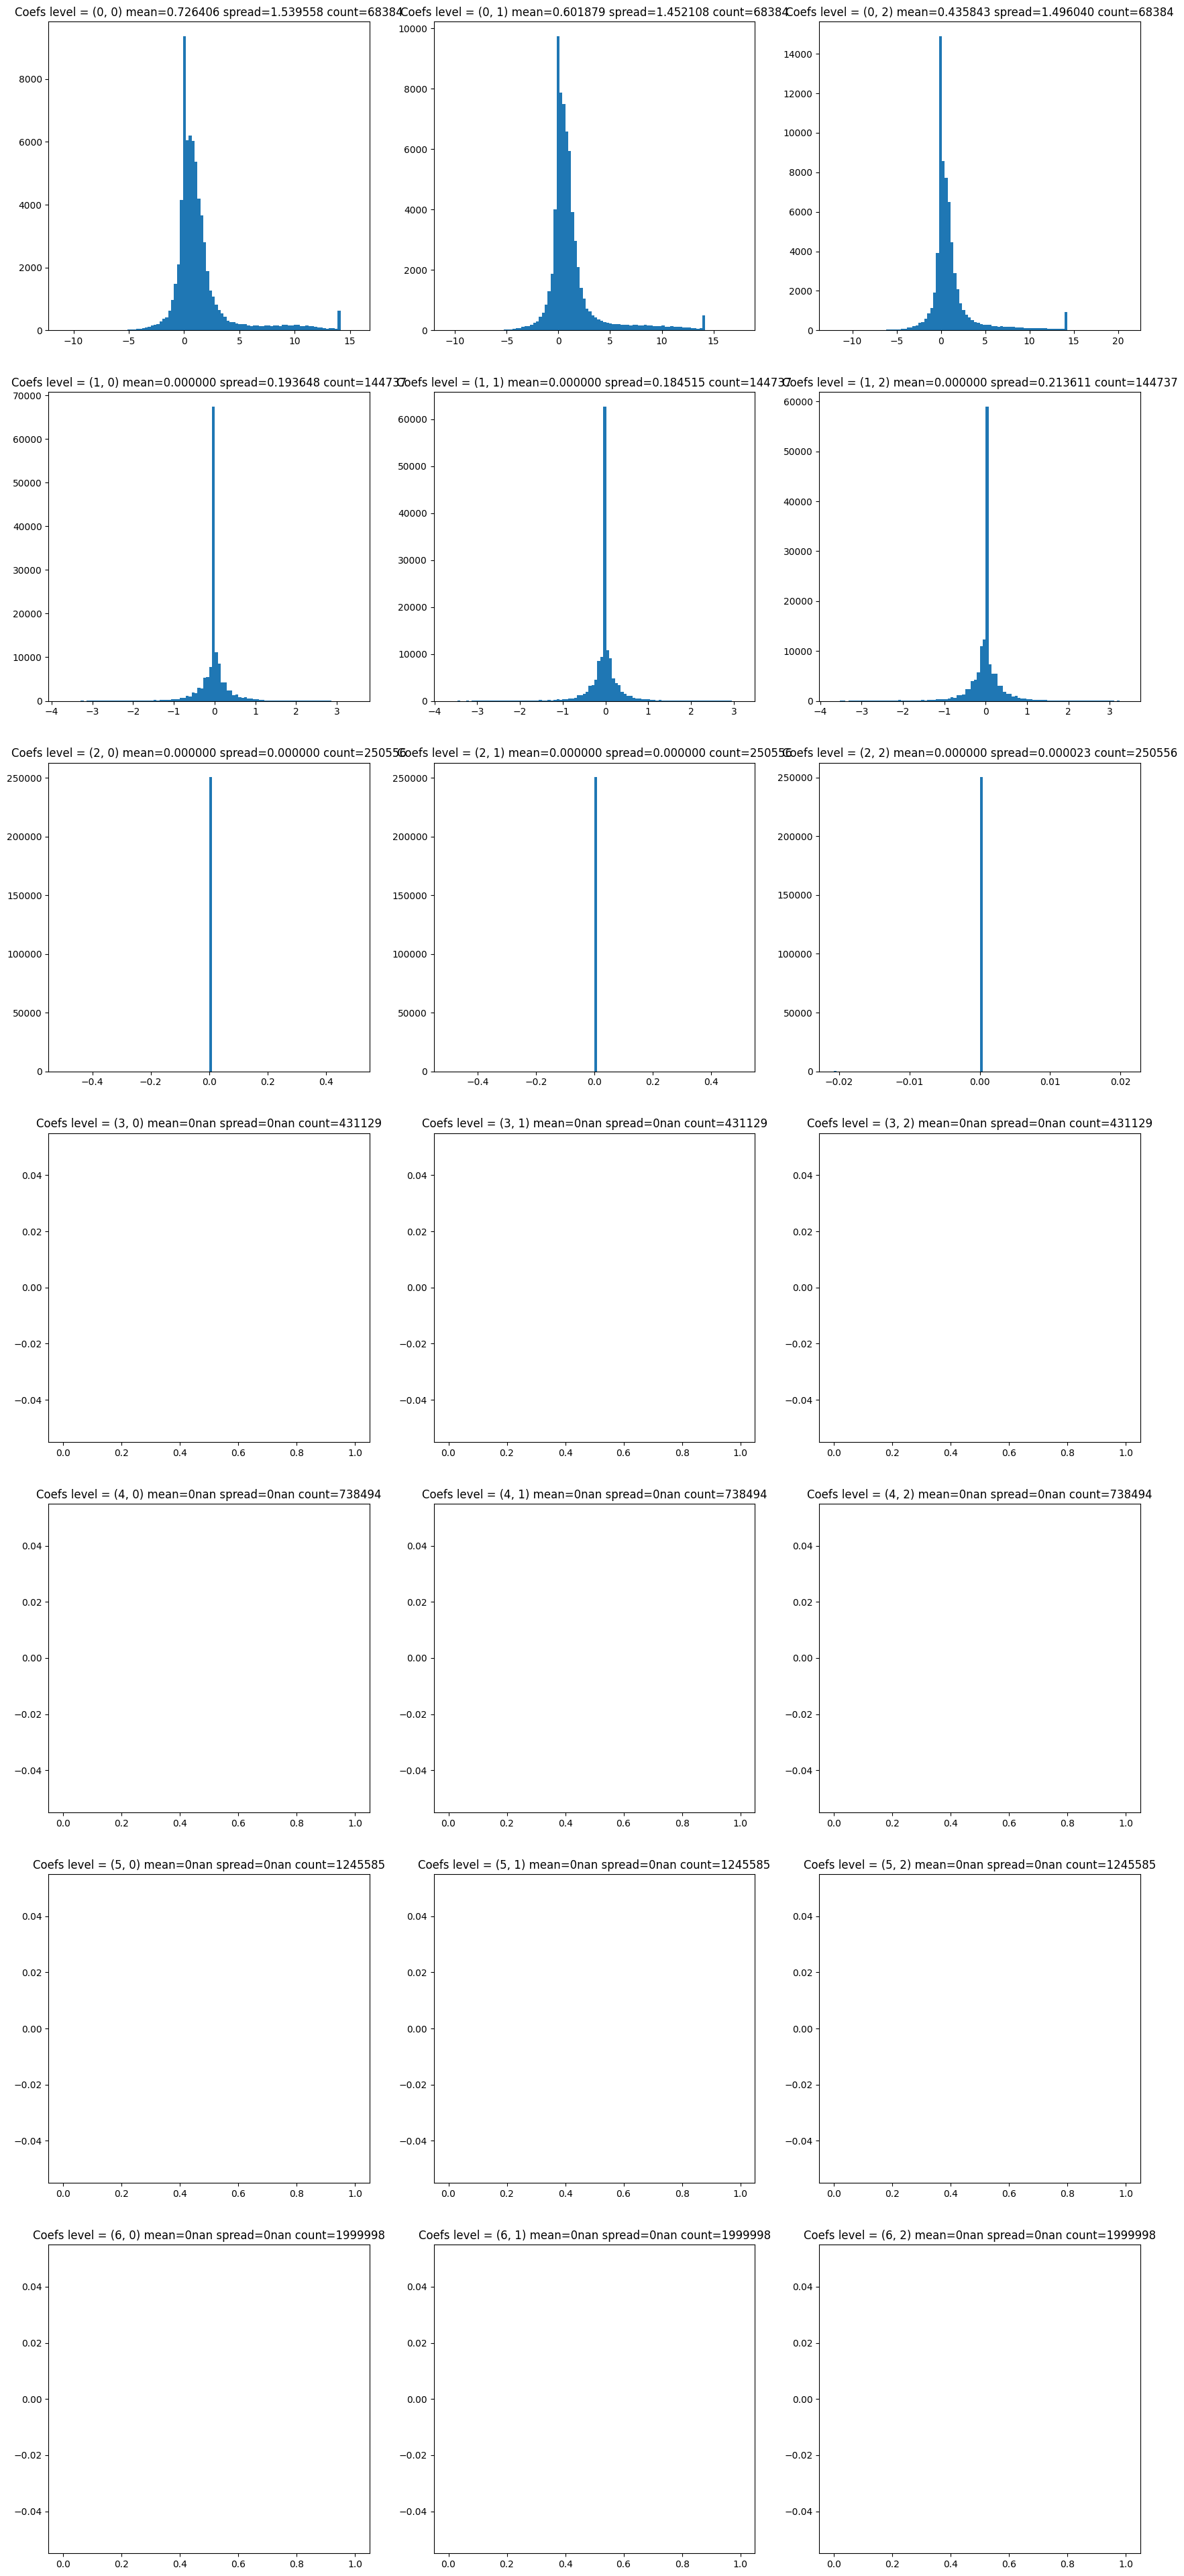

In [9]:
fig, ax = plt.subplots(ncols=3, nrows=len(all_quantized_coefs), figsize=(21, 7*len(all_quantized_coefs)))
for l, coefs in enumerate(all_quantized_coefs):
    for i in [0, 1, 2]:
        y = coefs[:, i].cpu().numpy()
        ind = (y > np.percentile(y, 0.01)) & (y < np.percentile(y, 99.99))

        a = np.median(y[ind])
        b = np.mean(np.abs(y[ind] - a))
        
        ax[l][i].hist(y[ind], bins=100)
        ax[l][i].set_title(f"Coefs level = {l, i} mean={a:04f} spread={b:04f} count={coefs.shape[0]}")
plt.show()

## 001 Learning


In [2]:
# iter = 3999 nvox = 53383 psnr = 20.455171800861184
# iter = 15999 nvox = 68384 psnr = 23.861671997851698
# iter = 26999 nvox = 144737 psnr = 24.82181125978562
# iter = 35999 nvox = 250556 psnr = 25.563771738778417
# iter = 42999 nvox = 431129 psnr = 26.16217433504914
# iter = 51999 nvox = 738494 psnr = 26.630531227057624
# iter = 59999 nvox = 1245585 psnr = 26.97370018154894
# iter = 87999 nvox = 1999998 psnr = 27.346640245272

#  iter003999_model, iter015999_model, iter026999_model, iter035999_model, iter042999_model, iter051999_model, iter059999_model, iter087999_model,
def im_tensor2np(x):
    if x.shape[0] == 1:
        x = x.squeeze(0)
    if len(x.shape) == 3:
        x = x.moveaxis(0, -1)
    return x.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)



torch.cuda.empty_cache()
encoder_learning = MultiScaleSplatsEncoder(
    scene_dataset_source_path="/home/dotamthuc-3090/Projects/ViewSynthesis/data/360_v2/kitchen/",
    list_density_field_paths=[
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter015999_model.pt", # 1
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter026999_model.pt", # 2
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter035999_model.pt", # 3
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter042999_model.pt", # 4
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter051999_model.pt", # 5
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter059999_model.pt", # 6
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter087999_model.pt", # 7
    ],
    num_sample_per_voxel=1,
    deltaQ=0.001,
    lambda_rate=0.0004,
    list_spread_b_init=[1.0, 0.2, 0.085, 0.05, 0.035, 0.025, 0.02], 
    scene_loader_opt={
        "res_downscale": 8,
        "res_width": 0,
        "encoder_view_every": 20
    },
    A_transpose_opt={
        "lr": 0.001,
        "num_scene_loop": 30,
    },
    rotation_opt={
        "max_degree": 6,
        "max_degree_grad": 6,
        "muy_phi": 0.9,
    },
    encoding_opts={
        "lr": 0.001,
        "num_loop": 5,
        "dmode": "coef_space" #coef_space / render_space
    },
    lowpass_rotation_opt = {
        "max_degree": 6,
        "max_degree_grad": 6,
        "muy_phi": 0.9,
    },
    lowpass_encoding_opts={
        "lr": 0.005,
        "num_loop": 5,
        "dmode": "coef_space" #coef_space / render_space
    }
)

checkpoint = torch.load("/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/encoding_checkpoints_v03/checkpoint_lambda04.pt", weights_only=True)
encoder_learning.trainable_params.load_state_dict(checkpoint["trainable_parameters"])



Read dataset in COLMAP format.
Done reading and creating views: 279 train views and 14 encoding views


<All keys matched successfully>

In [3]:
for outer_loop in range(1, 4):
    output = encoder_learning.learn_encoding()

    checkpoint = {
        "trainable_parameters": encoder_learning.trainable_params.state_dict()
    }
    torch.save(checkpoint, f"/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/encoding_checkpoints_v03/checkpoint_lambda04_re{outer_loop:02d}.pt")


    print("#"*80)
    all_quantized_coefs, decoded_attribute = encoder_learning.extract_learned_encoding()
    train_views = encoder_learning.scene_dataset.get_train_views()
    a_denfield= DensityField("/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter087999_model.pt")
    ref_denfield= DensityField("/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter087999_model.pt")

    list_mse = []
    for view in train_views:
        tensor_img = a_denfield.apply_phi_with_F(decoded_attribute, view).detach()
        rendered_img = tensor_img.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

        tensor_img_target = ref_denfield.apply_phi(view).detach()
        img_target = tensor_img_target.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

        mse = np.square(img_target/255 - rendered_img/255).mean()
        list_mse.append(mse)

    psnr = -10 * np.log10(np.mean(list_mse))

    deltaQ = torch.exp2(encoder_learning.trainable_params["log2_deltaQ"]).detach().cpu().numpy()
    transformed_attributes = torch.concatenate(all_quantized_coefs).detach().cpu().numpy().astype(np.float64)

    quantization_indices = np.round(
        np.array(transformed_attributes / deltaQ)
    ).astype(np.int64)

    # entropy coder
    rate = 0
    rate += rlgr.rlgr(quantization_indices[:, 0])
    rate += rlgr.rlgr(quantization_indices[:, 1])
    rate += rlgr.rlgr(quantization_indices[:, 2])


    print(f"RESULT LEARNING psnr = {psnr} bpv = {rate/ref_denfield.num_voxels}")

Start Encoding Process custom_encoding_opts={'lr': 0.005, 'num_loop': 5, 'dmode': 'coef_space'}


Encoding_attribute_field: TESTING loop = (0, 0) iter = 0 psnr=34.419100284576416 psnr_delta_field=25.378494262695312 rate=14.36621379852295 spread=[[1.9279 1.7613 1.7065]] deltaQ=[0.0719] 
Encoding_attribute_field: TESTING loop = (0, 100) iter = 100 psnr=34.184277057647705 psnr_delta_field=20.949020385742188 rate=15.186656951904297 spread=[[1.9732 1.8105 1.7551]] deltaQ=[0.0559] 
Encoding_attribute_field: TESTING loop = (0, 200) iter = 200 psnr=35.330095291137695 psnr_delta_field=19.06226921081543 rate=15.985675811767578 spread=[[2.0264 1.8655 1.8078]] deltaQ=[0.0438] 
Encoding_attribute_field: TESTING loop = (1, 21) iter = 300 psnr=36.08997344970703 psnr_delta_field=22.46828269958496 rate=16.698421478271484 spread=[[2.0697 1.9103 1.8509]] deltaQ=[0.0351] 
Encoding_attribute_field: TESTING loop = (1, 121) iter = 400 psnr=36.73091650009155 psnr_delta_field=24.703289031982422 rate=17.33171844482422 spread=[[2.1039 1.9459 1.8854]] deltaQ=[0.0288] 
Encoding_attribute_field: TESTING loop = 

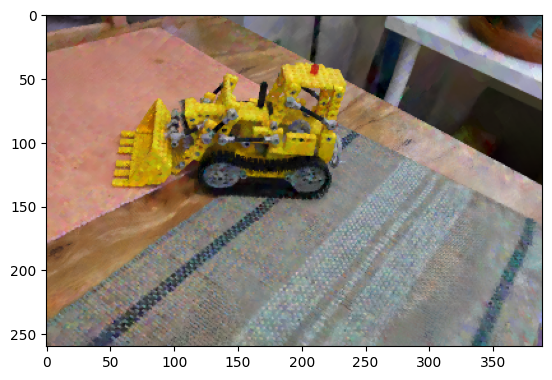

In [ ]:
plt.imshow(rendered_img)

# plt.title('Kitchen Scene at ~', fontsize=32)


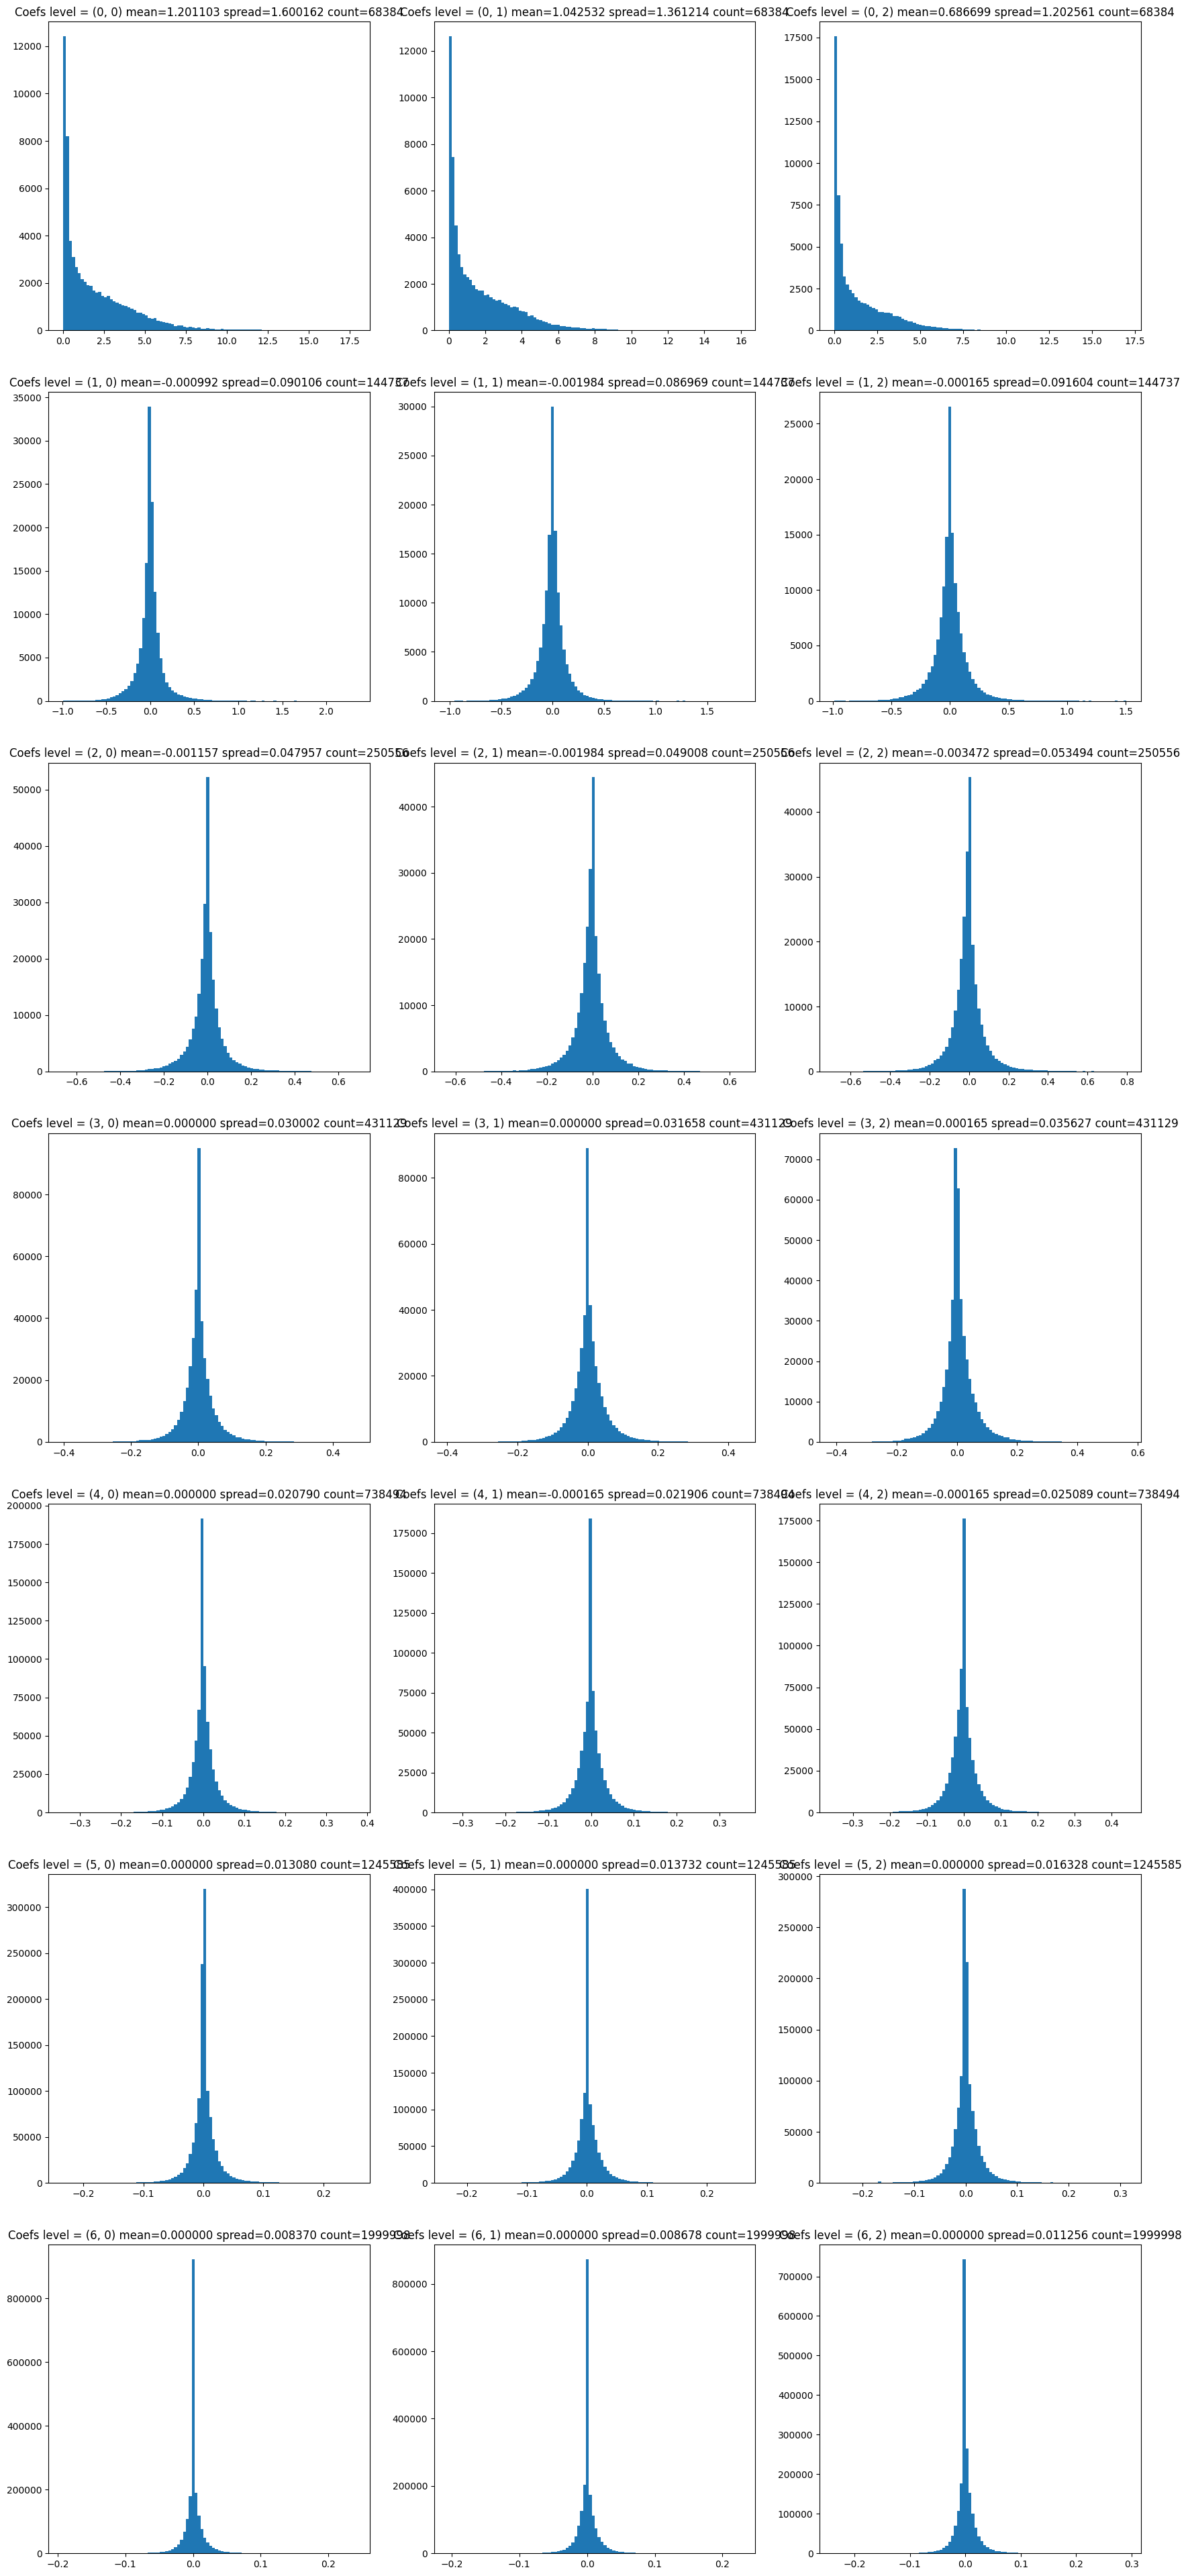

In [14]:
fig, ax = plt.subplots(ncols=3, nrows=len(all_quantized_coefs), figsize=(21, 7*len(all_quantized_coefs)))
for l, coefs in enumerate(all_quantized_coefs):
    for i in [0, 1, 2]:
        y = coefs[:, i].cpu().numpy()
        ind = (y > np.percentile(y, 0.01)) & (y < np.percentile(y, 99.99))

        a = np.median(y[ind])
        b = np.mean(np.abs(y[ind] - a))
        
        ax[l][i].hist(y[ind], bins=100)
        ax[l][i].set_title(f"Coefs level = {l, i} mean={a:04f} spread={b:04f} count={coefs.shape[0]}")
plt.show()

## Testing

In [2]:
# iter = 3999 nvox = 53383 psnr = 20.455171800861184
# iter = 15999 nvox = 68384 psnr = 23.861671997851698
# iter = 26999 nvox = 144737 psnr = 24.82181125978562
# iter = 35999 nvox = 250556 psnr = 25.563771738778417
# iter = 42999 nvox = 431129 psnr = 26.16217433504914
# iter = 51999 nvox = 738494 psnr = 26.630531227057624
# iter = 59999 nvox = 1245585 psnr = 26.97370018154894
# iter = 87999 nvox = 1999998 psnr = 27.346640245272

#  iter003999_model, iter015999_model, iter026999_model, iter035999_model, iter042999_model, iter051999_model, iter059999_model, iter087999_model,


torch.cuda.empty_cache()
encoder = MultiScaleSplatsEncoder(
    scene_dataset_source_path="/home/dotamthuc-3090/Projects/ViewSynthesis/data/360_v2/kitchen/",
    list_density_field_paths=[
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter015999_model.pt", # 1
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter026999_model.pt", # 2
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter035999_model.pt", # 3
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter042999_model.pt", # 4
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter051999_model.pt", # 5
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter059999_model.pt", # 6
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter087999_model.pt", # 7
    ],
    num_sample_per_voxel=1,
    deltaQ=0.001,
    lambda_rate=0.001,
    list_spread_b_init=[1.0, 0.2, 0.085, 0.05, 0.035, 0.025, 0.02], 
    scene_loader_opt={
        "res_downscale": 8,
        "res_width": 0,
        "encoder_view_every": 20
    },
    A_transpose_opt={
        "lr": 0.001,
        "num_scene_loop": 30,
    },
    rotation_opt={
        "max_degree": 3,
        "max_degree_grad": 3,
        "muy_phi": 0.9,
    },
    encoding_opts={
        "lr": 0.001,
        "num_loop": 10,
        "dmode": "coef_space" #coef_space / render_space
    },
    lowpass_rotation_opt = {
        "max_degree": 3,
        "max_degree_grad": 3,
        "muy_phi": 0.9,
    },
    lowpass_encoding_opts={
        "lr": 0.005,
        "num_loop": 10,
        "dmode": "coef_space" #coef_space / render_space
    }
)


Read dataset in COLMAP format.
Done reading and creating views: 279 train views and 14 encoding views


In [34]:

checkpoint = torch.load("/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/encoding_checkpoints_v01/checkpoint_lambda00_te00_re00.pt", weights_only=True)
encoder.trainable_params.load_state_dict(checkpoint["trainable_parameters"])


<All keys matched successfully>

In [5]:
i = 3
encoder.lowpass_rotation_opt["max_degree"]      = encoder.lowpass_rotation_opt["max_degree"] + i
encoder.lowpass_rotation_opt["max_degree_grad"] = encoder.lowpass_rotation_opt["max_degree_grad"] + i
encoder.rotation_opt["max_degree"]              = encoder.rotation_opt["max_degree"] + i
encoder.rotation_opt["max_degree_grad"]         = encoder.rotation_opt["max_degree_grad"] + i

checkpoint = torch.load(f"/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/encoding_checkpoints_v01/checkpoint_lambda00_te00_re{i:02d}.pt", weights_only=True)
encoder.trainable_params.load_state_dict(checkpoint["trainable_parameters"])


<All keys matched successfully>

In [6]:
all_quantized_coefs, decoded_attribute = encoder.extract_learned_encoding()

Extract encoding level=1
Apply_A_transpose: loop = (0, 0) iter = 0 psnr=14.109708070755005
Apply_A_transpose: loop = (1, 221) iter = 500 psnr=20.291738510131836
Apply_A_transpose: loop = (3, 163) iter = 1000 psnr=24.485065937042236
Apply_A_transpose: loop = (5, 105) iter = 1500 psnr=27.27550506591797
Apply_A_transpose: loop = (7, 47) iter = 2000 psnr=29.097561836242676
Apply_A_transpose: loop = (8, 268) iter = 2500 psnr=29.996178150177002
Apply_A_transpose: loop = (10, 210) iter = 3000 psnr=30.54149866104126
Apply_A_transpose: loop = (12, 152) iter = 3500 psnr=30.676376819610596
Apply_A_transpose: loop = (14, 94) iter = 4000 psnr=30.832746028900146
Apply_A_transpose: loop = (16, 36) iter = 4500 psnr=30.947012901306152
Apply_A_transpose: loop = (17, 257) iter = 5000 psnr=30.923080444335938
Apply_A_transpose: loop = (19, 199) iter = 5500 psnr=30.924675464630127
Apply_A_transpose: loop = (21, 141) iter = 6000 psnr=30.902929306030273
Apply_A_transpose: loop = (23, 83) iter = 6500 psnr=30.9

In [35]:
all_real_coefs = [encoder.trainable_params["list_learned_coefs"][i].detach().cpu().numpy() for i in range(len(encoder.trainable_params["list_learned_coefs"]))]

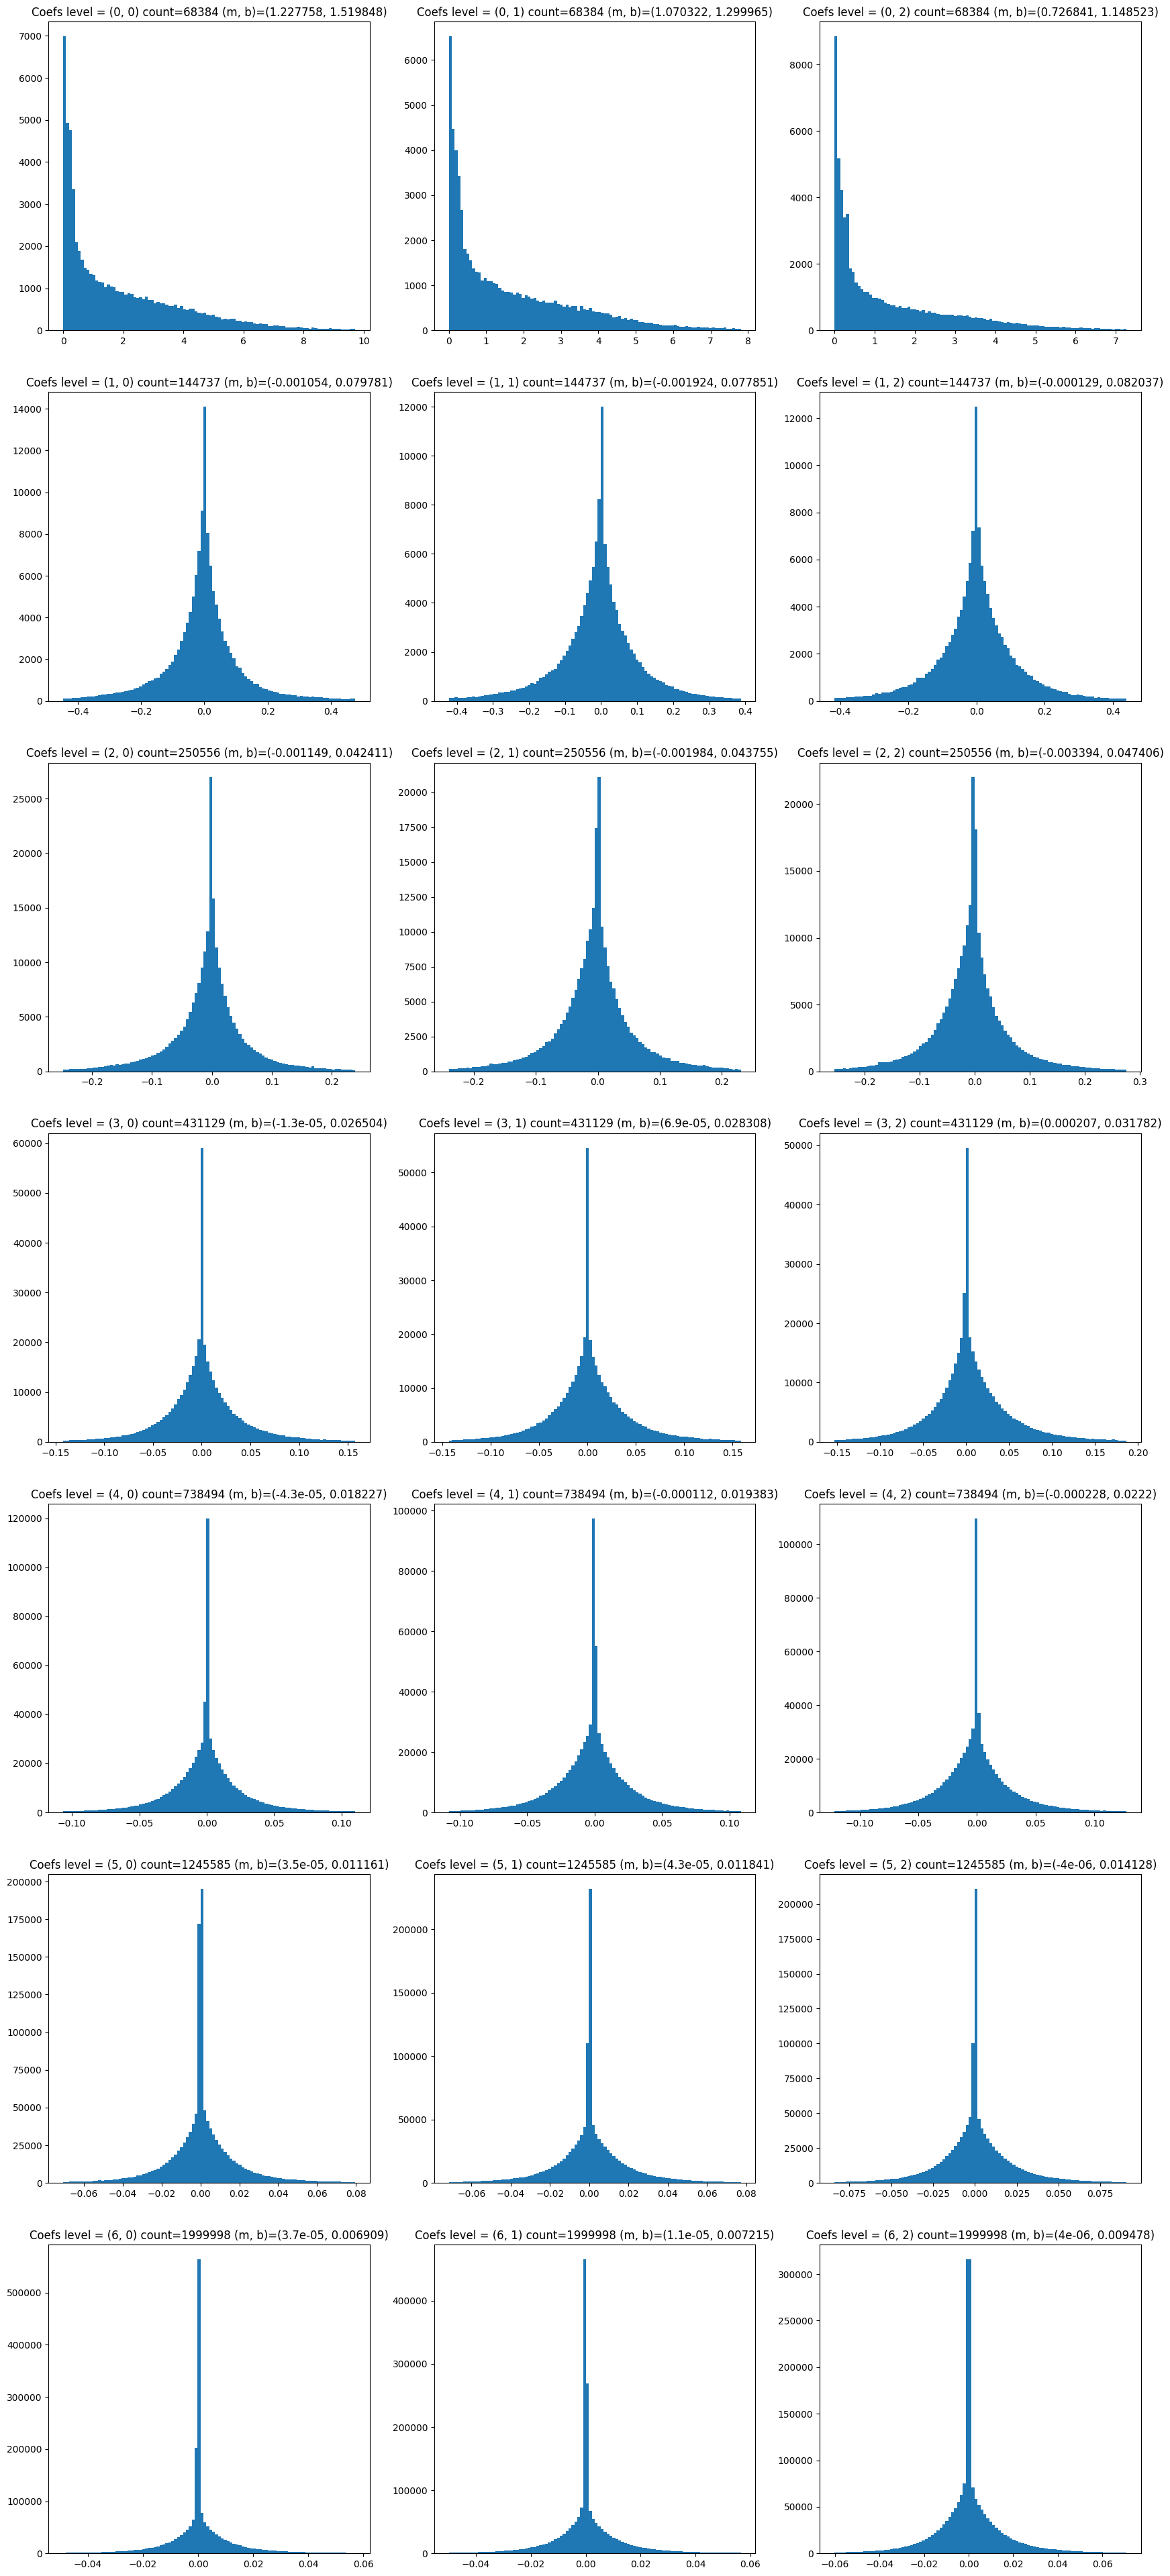

In [36]:
fig, ax = plt.subplots(ncols=3, nrows=len(all_real_coefs), figsize=(21, 7*len(all_real_coefs)))
for l, coefs in enumerate(all_real_coefs):
    for i in [0, 1, 2]:
        y = coefs[:, i]
        ind = (y > np.percentile(y, 1)) & (y < np.percentile(y, 99))

        a = np.round(np.median(y[ind]), 6)
        b = np.round(np.mean(np.abs(y[ind] - a)), 6)
        
        ax[l][i].hist(y[ind], bins=100)
        ax[l][i].set_title(f"Coefs level = {l, i} count={coefs.shape[0]} (m, b)={(a, b)}")
plt.show()

In [29]:
y

array([ 1.0590e-04,  1.9402e-05, -1.6512e-04, ..., -1.4856e-04,  1.1987e-05,  3.3927e-05], dtype=float32)

In [8]:
train_views = encoder.scene_dataset.get_train_views()
test_views = encoder.scene_dataset.get_encoder_views()

ref_denfield= DensityField("/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter087999_model.pt")

def im_tensor2np(x):
    if x.shape[0] == 1:
        x = x.squeeze(0)
    if len(x.shape) == 3:
        x = x.moveaxis(0, -1)
    return x.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)


list_mse = []
for view in train_views:
    tensor_img = ref_denfield.apply_phi_with_F(decoded_attribute, view).detach()
    rendered_img = tensor_img.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

    tensor_img_target = ref_denfield.apply_phi(view).detach()
    img_target = tensor_img_target.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

    mse = np.square(img_target/255 - rendered_img/255).mean()
    list_mse.append(mse)

psnr = -10 * np.log10(np.mean(list_mse))
print(f"psnr = {psnr}")

psnr = 24.024078364062625


In [27]:
deltaQ = torch.exp2(encoder.trainable_params["log2_deltaQ"]).detach().cpu().numpy()
transformed_attributes = torch.concatenate(all_quantized_coefs).detach().cpu().numpy().astype(np.float64)

quantization_indices = np.round(
    np.array(transformed_attributes / deltaQ)
).astype(np.int64)


# entropy coder
rate = 0
rate += rlgr.rlgr(quantization_indices[:, 0])
rate += rlgr.rlgr(quantization_indices[:, 1])
rate += rlgr.rlgr(quantization_indices[:, 2])

bpv = rate/ref_denfield.num_voxels

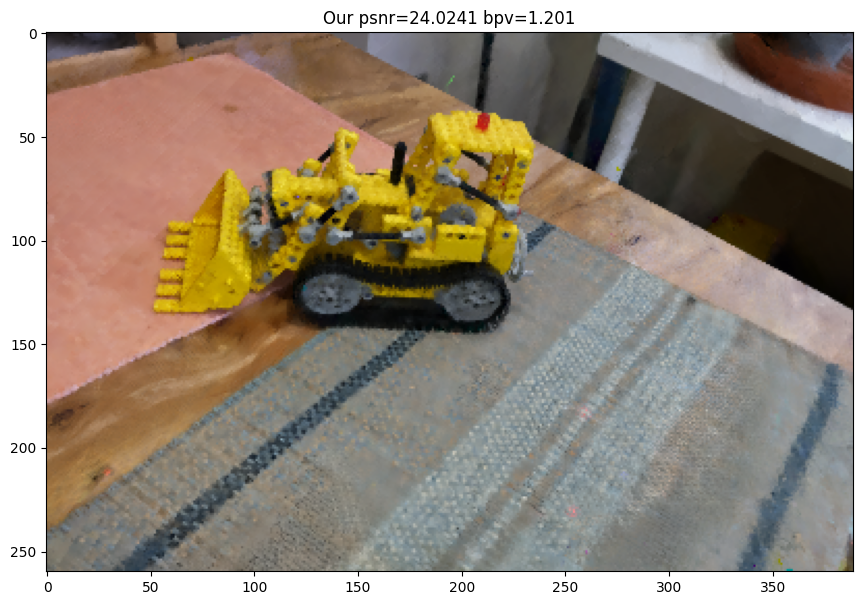

In [28]:
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(12, 7))
ax.imshow(rendered_img)
ax.set_title(f"Our psnr={np.round(psnr, 4)} bpv={np.round(bpv, 4)}")
plt.show()

# bbb

In [8]:
train_views = encoder.scene_dataset.get_train_views()
test_views = encoder.scene_dataset.get_encoder_views()


a_denfield= DensityField("/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter059999_model.pt")
ref_denfield= DensityField("/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter087999_model.pt")

def im_tensor2np(x):
    if x.shape[0] == 1:
        x = x.squeeze(0)
    if len(x.shape) == 3:
        x = x.moveaxis(0, -1)
    return x.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)


list_mse = []
for view in train_views:
    tensor_img = a_denfield.apply_phi(view).detach()
    rendered_img = tensor_img.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

    tensor_img_target = view.rendered_true
    img_target = im_tensor2np(tensor_img_target)

    mse = np.square(img_target/255 - rendered_img/255).mean()
    list_mse.append(mse)

psnr = -10 * np.log10(np.mean(list_mse))
print(f"psnr = {psnr}")

psnr = 26.97370018154894


In [9]:
train_views = encoder.scene_dataset.get_train_views()
test_views = encoder.scene_dataset.get_encoder_views()


a_denfield= DensityField("/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter059999_model.pt")
ref_denfield= DensityField("/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter087999_model.pt")

def im_tensor2np(x):
    if x.shape[0] == 1:
        x = x.squeeze(0)
    if len(x.shape) == 3:
        x = x.moveaxis(0, -1)
    return x.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)


list_mse = []
for view in train_views:
    tensor_img = ref_denfield.apply_phi(view).detach()
    rendered_img = tensor_img.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

    tensor_img_target = view.rendered_true
    img_target = im_tensor2np(tensor_img_target)

    mse = np.square(img_target/255 - rendered_img/255).mean()
    list_mse.append(mse)

psnr = -10 * np.log10(np.mean(list_mse))
print(f"psnr = {psnr}")

psnr = 27.346640245272


In [4]:
train_views = encoder.scene_dataset.get_train_views()
test_views = encoder.scene_dataset.get_encoder_views()


a_denfield= DensityField("/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter059999_model.pt")

ref_denfield= DensityField("/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter087999_model.pt")

def im_tensor2np(x):
    if x.shape[0] == 1:
        x = x.squeeze(0)
    if len(x.shape) == 3:
        x = x.moveaxis(0, -1)
    return x.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)


list_mse = []
for view in train_views:
    tensor_img = a_denfield.apply_phi(view).detach()
    rendered_img = tensor_img.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

    tensor_img_target = ref_denfield.apply_phi(view).detach()
    img_target = tensor_img_target.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

    mse = np.square(img_target/255 - rendered_img/255).mean()
    list_mse.append(mse)

psnr = -10 * np.log10(np.mean(list_mse))
print(f"psnr = {psnr}")

psnr = 31.334566176633658


# END